In [2]:
import numpy as np
import pandas as pd

In [59]:
# Load data efficiently
df = pd.read_csv("terrestrial_ebird_count_habitat_no_year.csv")
df_o = pd.read_csv("terrestrial_ebird_occurance_habitat_no_year.csv", dtype='str')
# Store column names for later use
all_columns = df.columns.tolist()
feature_names = all_columns[1:34]  # Features are columns 1-33
label_names = all_columns[34:438]  # Labels are columns 34-437

# Convert to numpy for processing
data = df.to_numpy()
data_o = df_o.to_numpy()
# Remove rows with all zeros in labels
count_label = data[:, 34:438]
binary_label = data_o[:, 34:438]
non_zero_idx = np.where(np.sum(binary_label, axis=1) != 0)[0]

# Extract features and labels with non-zero rows
count_label = data[non_zero_idx, 34:438]
feat = data[non_zero_idx, 1:34]
binary_label = data_o[non_zero_idx, 34:438]
# Remove columns with all zeros in labels
binary_label = binary_label.astype(np.float32)
non_zero_col_idx = np.where(np.sum(binary_label, axis=0) >= 10)[0]
label = count_label[:, non_zero_col_idx]

# Update label names to match the filtered columns
filtered_label_names = [label_names[i] for i in non_zero_col_idx]

feat = feat.astype(np.float32)
label = label.astype(np.float32)
np.savez_compressed("ebird_data.npz", feat=feat, count_label=label, 
                   feature_names=feature_names, label_names=filtered_label_names)

print("Total number of rows:", len(data))
print("Number of rows with non-zero labels:", len(non_zero_idx))
print(f"Removed {len(data) - len(non_zero_idx)} rows with all zeros.")
print(f"Total number of species columns: {len(label_names)}")
print(f"Number of species columns with non-zero counts: {len(non_zero_col_idx)}")
print(f"Removed {len(label_names) - len(non_zero_col_idx)} species columns with all zeros.")

Total number of rows: 115532
Number of rows with non-zero labels: 115532
Removed 0 rows with all zeros.
Total number of species columns: 404
Number of species columns with non-zero counts: 350
Removed 54 species columns with all zeros.


In [46]:
count_metrics = pd.read_csv("count_metrics.csv")
low_rmse_label = count_metrics.loc[count_metrics["RMSE"] < 1, "Label"]
low_rmse_label

0              Acadian Flycatcher
1                Alder Flycatcher
2             Allen's Hummingbird
4                American Bittern
7          American Golden-Plover
                  ...            
343          Yellow-billed Cuckoo
344          Yellow-breasted Chat
345    Yellow-crowned Night Heron
346       Yellow-headed Blackbird
349       Yellow-throated Warbler
Name: Label, Length: 206, dtype: object

In [56]:
# Load data efficiently
df = pd.read_csv("terrestrial_ebird_count_habitat_no_year.csv")
df_o = pd.read_csv("terrestrial_ebird_occurance_habitat_no_year.csv", dtype='str')
# Store column names for later use
all_columns = df.columns.tolist()
feature_names = all_columns[1:34]  # Features are columns 1-33
label_names = all_columns[34:438]  # Labels are columns 34-437

# Convert to numpy for processing
data = df.to_numpy()
data_o = df_o.to_numpy()
# Remove rows with all zeros in labels
count_label = data[:, 34:438]
binary_label = data_o[:, 34:438]
non_zero_idx = np.where(np.sum(binary_label, axis=1) != 0)[0]

# Extract features and labels with non-zero rows
count_label = data[non_zero_idx, 34:438]
feat = data[non_zero_idx, 1:34]
binary_label = data_o[non_zero_idx, 34:438]
# Remove columns with all zeros in labels
binary_label = binary_label.astype(np.float32)
non_zero_col_idx = np.where(np.sum(binary_label, axis=0) >= 10)[0]
label = count_label[:, non_zero_col_idx]

# 'label_names' should be a list of column names corresponding to columns in 'label'
label_names = count_metrics["Label"].tolist()

# Get indices for the low RMSE labels
low_rmse_indices = [label_names.index(name) for name in low_rmse_label]

# Use them to slice the array
filtered_label = label[:, low_rmse_indices]

# Update label names to match the filtered columns
filtered_label_names = [label_names[i] for i in low_rmse_indices]

feat = feat.astype(np.float32)
label = label.astype(np.float32)
np.savez_compressed("ebird_data1.npz", feat=feat, count_label=filtered_label, 
                   feature_names=feature_names, label_names=filtered_label_names)

print("Total number of rows:", len(data))
print("Number of rows with non-zero labels:", len(non_zero_idx))
print(f"Removed {len(data) - len(non_zero_idx)} rows with all zeros.")
print(f"Total number of species columns: {len(filtered_label_names)}")
print(f"Number of species columns with non-zero counts: {len(non_zero_col_idx)}")
print(f"Removed {len(low_rmse_label)} species columns with satisfying rsme.")
print(f"Removed {len(label_names) - len(non_zero_col_idx)} species columns with all zeros.")

Total number of rows: 115532
Number of rows with non-zero labels: 115532
Removed 0 rows with all zeros.
Total number of species columns: 206
Number of species columns with non-zero counts: 350
Removed 206 species columns with satisfying rsme.
Removed 0 species columns with all zeros.


In [57]:
# Load the saved compressed data
data = np.load("ebird_data1.npz", allow_pickle=True)
feat = data['feat']
print(data)
label = data['count_label']
feature_names = data['feature_names']
label_names = data['label_names']

print(f"Features shape: {feat.shape}, {feat.dtype}")
print(f"Labels shape: {label.shape}, {label.dtype}")

NpzFile 'ebird_data1.npz' with keys: feat, count_label, feature_names, label_names
Features shape: (115532, 33), float32
Labels shape: (115532, 206), object


## Feature Analysis

Let's analyze the feature columns (columns 1-33 from the original dataset). We'll summarize the zero/non-zero counts and visualize their distributions.

In [7]:
# Summarize features
feat_summary = {}

for i in range(feat.shape[1]):
    col = feat[:, i]
    col_name = feature_names[i]
    zero_count = np.sum(col == 0)
    non_zero_count = len(col) - zero_count
    
    feat_summary[col_name] = {
        'zero_count': zero_count,
        'non_zero_count': non_zero_count,
        'zero_percentage': zero_count / len(col) * 100,
        'min': np.min(col),
        'max': np.max(col),
        'mean': np.mean(col),
        'median': np.median(col)
    }

# Convert to DataFrame for better visualization
feat_df = pd.DataFrame(feat_summary).T
feat_df

,zero_count,non_zero_count,zero_percentage,min,max,mean,median
latitude,0.0,115532.0,0.000000,2.896578e+01,31.249952,30.328182,30.363373
longitude,0.0,115532.0,0.000000,-9.074992e+01,-84.999901,-88.341484,-88.275467
protocol_type,51006.0,64526.0,44.148807,0.000000e+00,1.000000,0.558512,1.000000
day_of_year,0.0,115532.0,0.000000,1.000000e+00,366.000000,169.294083,145.000000
time_observations_started,8.0,115524.0,0.006924,0.000000e+00,23.983334,11.212766,10.500000
duration_minutes,0.0,115532.0,0.000000,1.000000e+00,300.000000,58.064156,42.000000
effort_distance_km,51032.0,64500.0,44.171312,0.000000e+00,5.000000,0.928027,0.322000
number_observers,0.0,115532.0,0.000000,1.000000e+00,10.000000,1.301362,1.000000
barren,9026.0,106506.0,7.812554,0.000000e+00,0.286074,0.021142,0.004288
forest,14959.0,100573.0,12.947928,0.000000e+00,0.891589,0.110622,0.050183


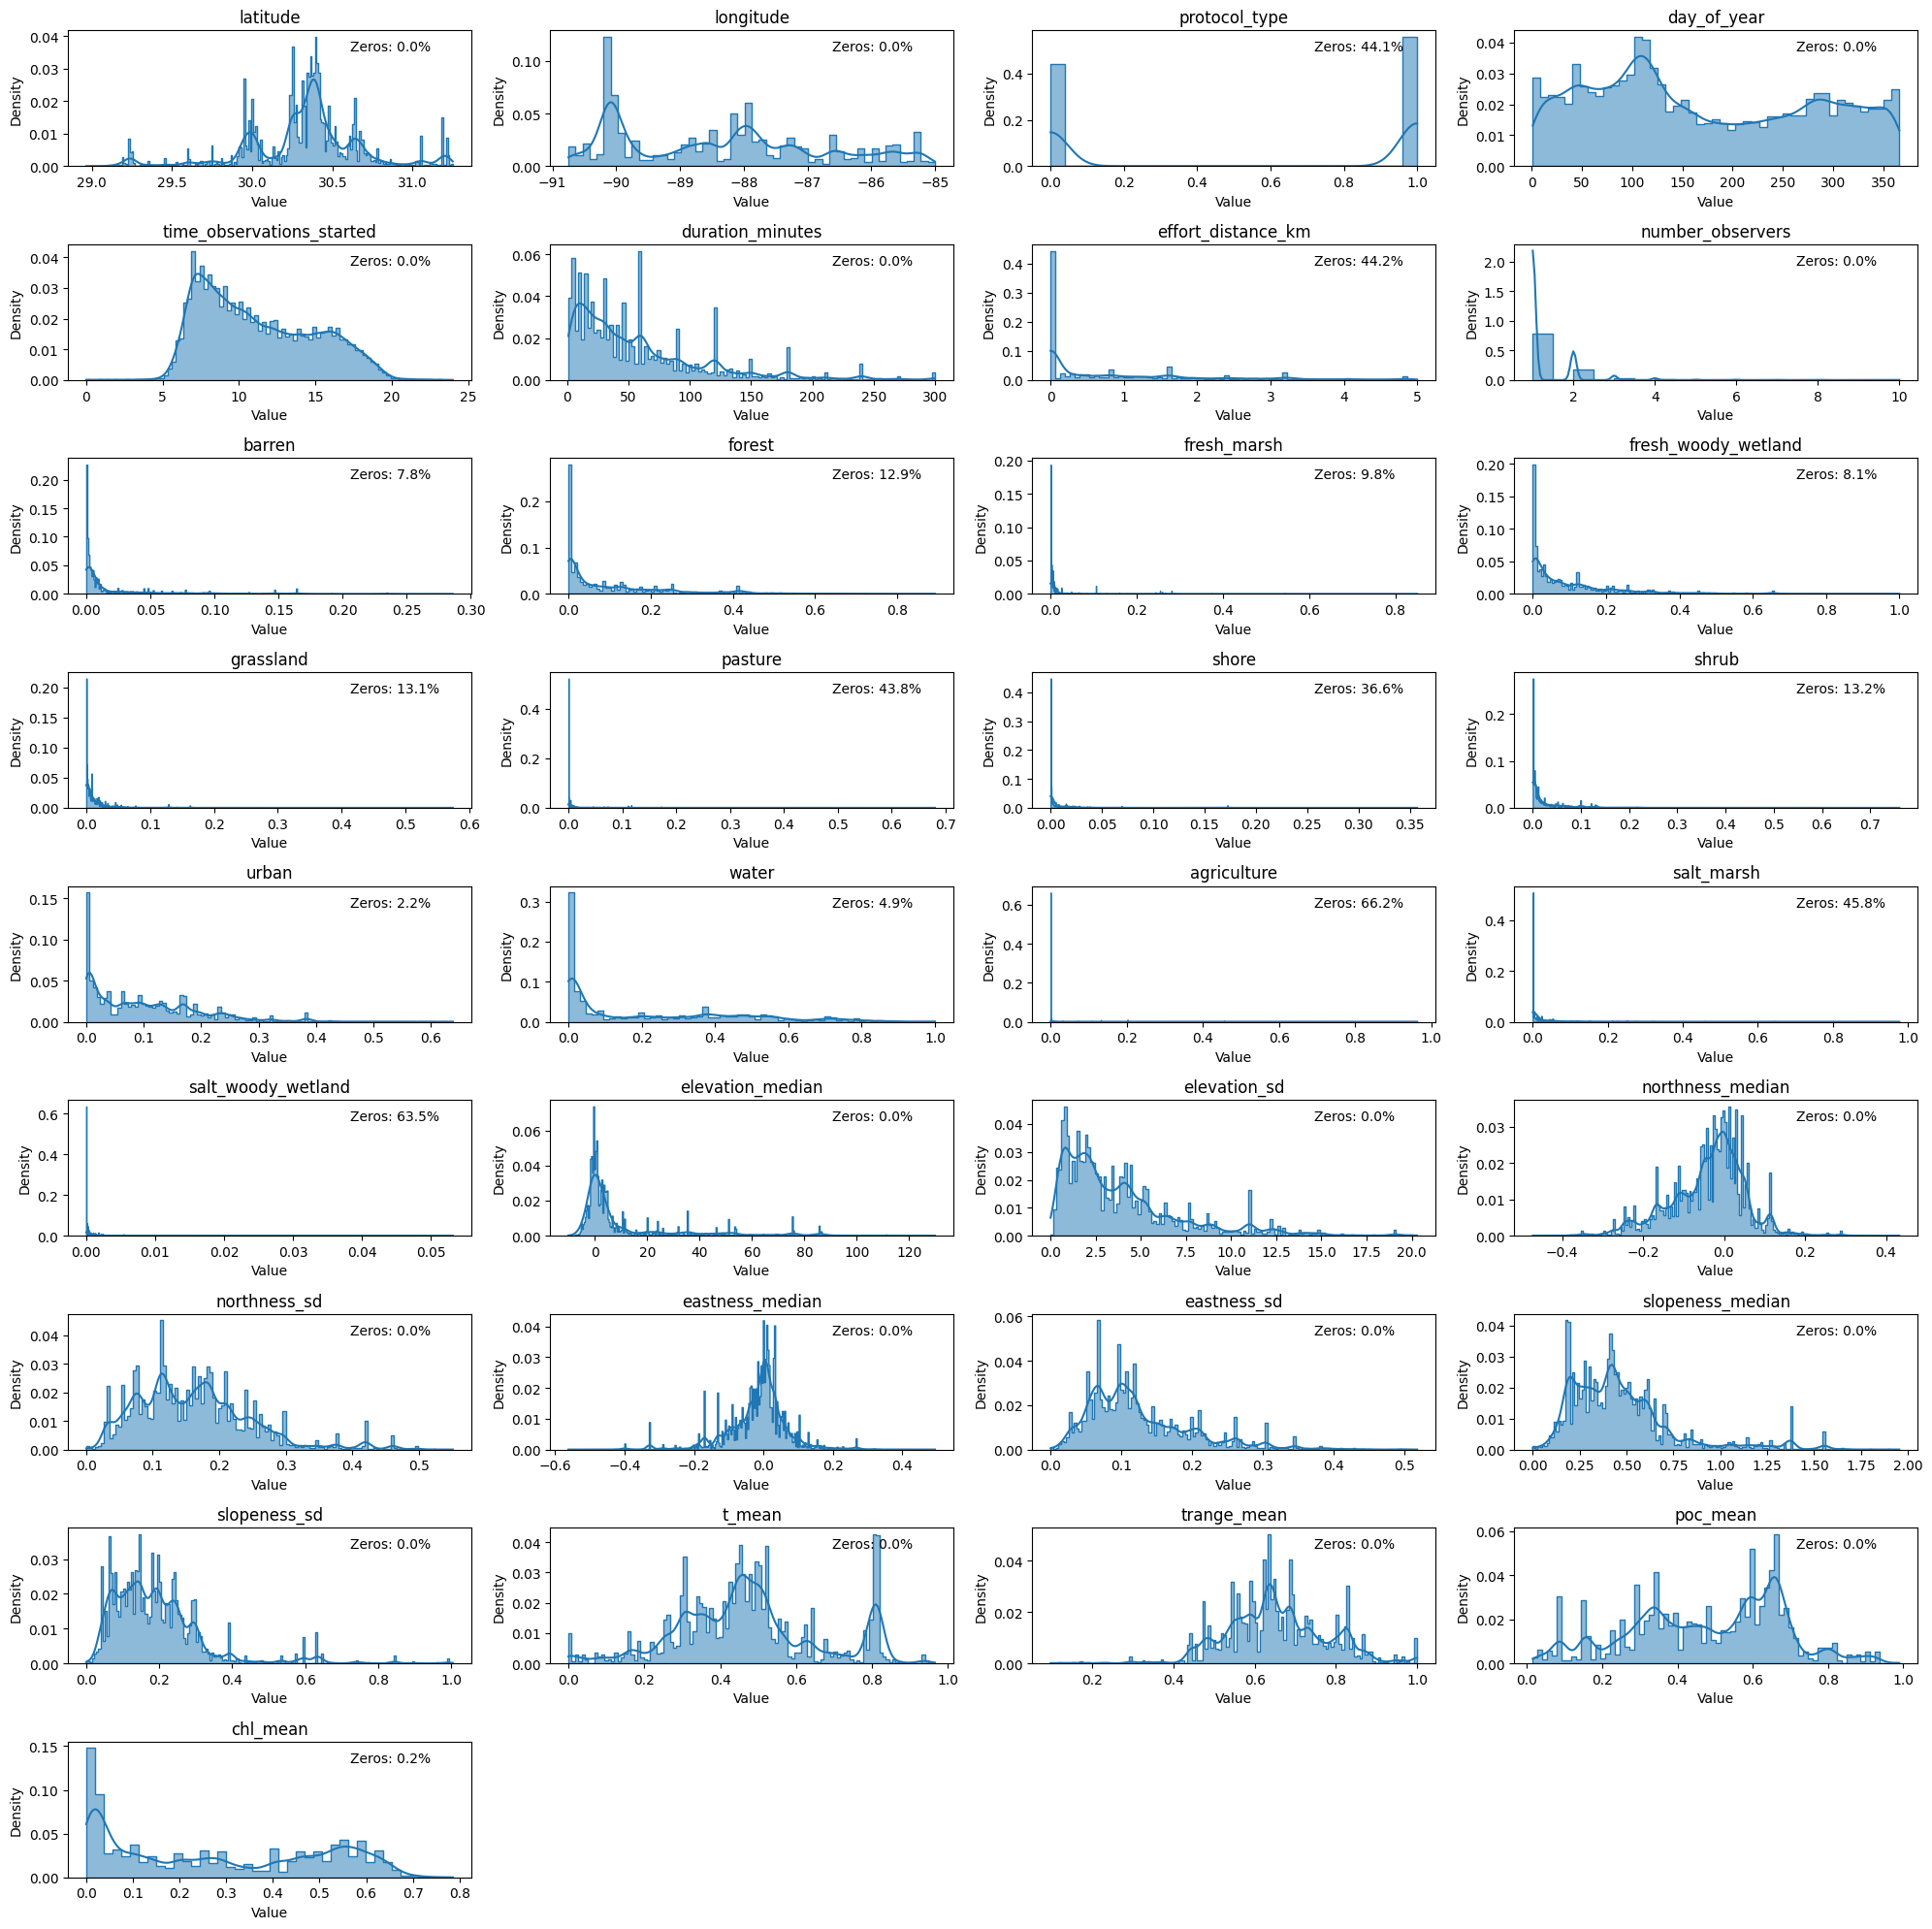

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure for feature histograms
plt.figure(figsize=(20, 20))

# Create a grid of subplots based on the number of features
n_features = feat.shape[1]
rows = (n_features + 3) // 4  # Calculate number of rows needed (4 columns per row)

# Plot histograms for each feature
for i in range(n_features):
    plt.subplot(rows, 4, i+1)
    
    # Get feature data and name
    col_data = feat[:, i]
    col_name = feature_names[i]
    
    # Plot normalized histogram
    sns.histplot(col_data, kde=True, stat='probability', element='step')
    plt.title(f'{col_name}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    
    # Add text with zero/non-zero counts
    zero_pct = feat_summary[col_name]['zero_percentage']
    plt.annotate(f'Zeros: {zero_pct:.1f}%', xy=(0.7, 0.85), xycoords='axes fraction')

plt.tight_layout()
plt.show()

## Label Analysis

Let's analyze the label columns (species counts, columns 34-437 from the original dataset). We'll summarize the zero/non-zero counts and visualize their distributions.

In [58]:
# Analyze all label columns

# Summarize labels
label_summary = {}

for i in range(label.shape[1]):
    col = label[:, i]
    col_name = label_names[i]
    zero_count = np.sum(col == 0)
    non_zero_count = len(col) - zero_count
    
    label_summary[col_name] = {
        'zero_count': zero_count,
        'non_zero_count': non_zero_count,
        'zero_percentage': zero_count / len(col) * 100,
        'min': np.min(col),
        'max': np.max(col),
        'mean': np.mean(col),
        'median': np.median(col)
    }

# Create overall summary for all labels
label_zeros = np.sum(label == 0)
total_elements = label.size
label_non_zeros = total_elements - label_zeros

print(f"Overall Label Statistics:")
print(f"Total elements: {total_elements}")
print(f"Zero elements: {label_zeros} ({label_zeros/total_elements*100:.2f}%)")
print(f"Non-zero elements: {label_non_zeros} ({label_non_zeros/total_elements*100:.2f}%)")

# Convert to DataFrame for better visualization (showing all labels)
label_df = pd.DataFrame(label_summary).T

# Display summary statistics
print("\nLabel Summary Statistics:")
print(f"Number of labels: {len(label_df)}")
print(f"Average zero percentage: {label_df['zero_percentage'].mean():.2f}%")
print(f"Median zero percentage: {label_df['zero_percentage'].median():.2f}%")
print(f"Max zero percentage: {label_df['zero_percentage'].max():.2f}%")
print(f"Min zero percentage: {label_df['zero_percentage'].min():.2f}%")

label_df.to_csv("label_summary.csv", index=True)

Overall Label Statistics:
Total elements: 23799592
Zero elements: 23626173 (99.27%)
Non-zero elements: 173419 (0.73%)

Label Summary Statistics:
Number of labels: 206
Average zero percentage: 99.27%
Median zero percentage: 99.79%
Max zero percentage: 99.99%
Min zero percentage: 91.29%


## Correlation Analysis

Let's analyze the correlations between features and between labels to identify patterns and relationships in the data.

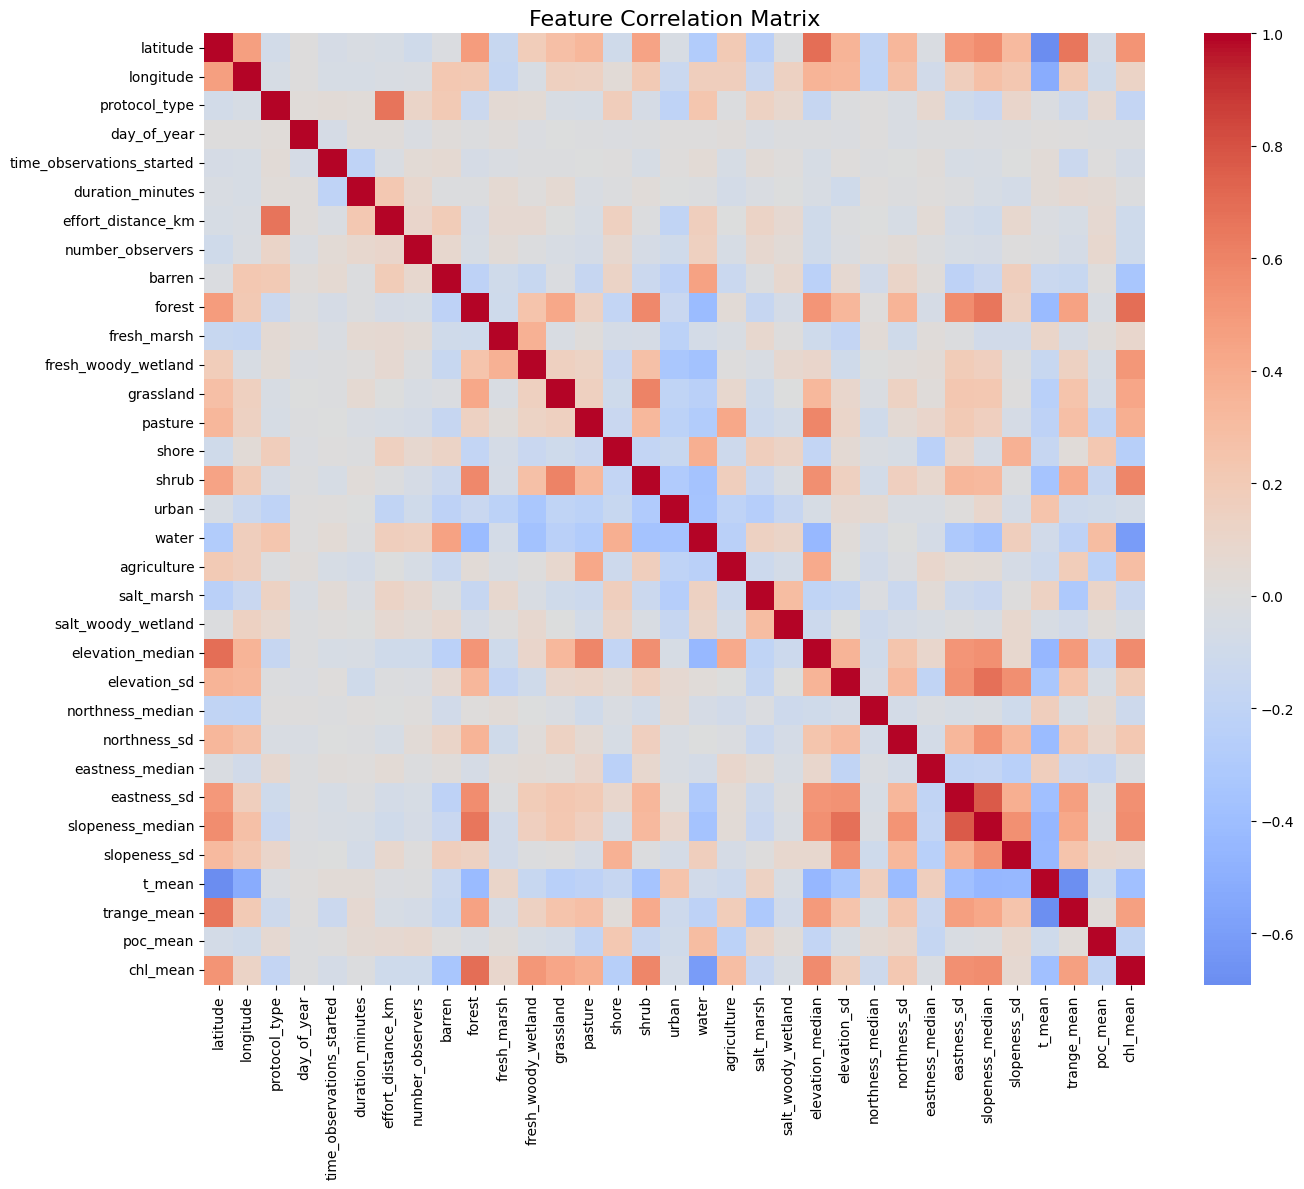

Highly correlated feature pairs (|correlation| > 0.5):
eastness_sd & slopeness_median: 0.764
latitude & elevation_median: 0.695
latitude & t_mean: -0.691
forest & chl_mean: 0.687
t_mean & trange_mean: -0.683
elevation_sd & slopeness_median: 0.682
protocol_type & effort_distance_km: 0.666
forest & slopeness_median: 0.660
latitude & trange_mean: 0.660
water & chl_mean: -0.608
grassland & shrub: 0.606
pasture & elevation_median: 0.589
shrub & chl_mean: 0.587
forest & shrub: 0.581
elevation_median & chl_mean: 0.569
slopeness_median & chl_mean: 0.560
forest & eastness_sd: 0.559
latitude & slopeness_median: 0.558
shrub & elevation_median: 0.550
elevation_sd & slopeness_sd: 0.548
elevation_median & slopeness_median: 0.542
eastness_sd & chl_mean: 0.541
slopeness_median & slopeness_sd: 0.540
elevation_sd & eastness_sd: 0.537
northness_sd & slopeness_median: 0.527
latitude & chl_mean: 0.526
forest & elevation_median: 0.521
longitude & t_mean: -0.519
elevation_median & eastness_sd: 0.514
fresh_wo

In [23]:
# Feature correlation analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix for features
feat_df = pd.DataFrame(feat, columns=feature_names)
feat_corr = feat_df.corr()

# Plot correlation heatmap for features
plt.figure(figsize=(14, 12))
sns.heatmap(feat_corr, annot=False, cmap='coolwarm', center=0, 
            xticklabels=feat_corr.columns, yticklabels=feat_corr.columns)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs
feat_corr_pairs = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        if abs(feat_corr.iloc[i, j]) > 0.5:  # Threshold for high correlation
            feat_corr_pairs.append((feature_names[i], feature_names[j], feat_corr.iloc[i, j]))

# Display highly correlated feature pairs
if feat_corr_pairs:
    print("Highly correlated feature pairs (|correlation| > 0.5):")
    for pair in sorted(feat_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{pair[0]} & {pair[1]}: {pair[2]:.3f}")
else:
    print("No feature pairs with correlation above 0.5 found.")